<a href="https://colab.research.google.com/github/student-uzma/CSL701-CS10_Machine-Learning-Lab/blob/main/ML_EXP2_CS10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Uzma Choudhary Roll no : CS10 Batch :cs01

#Experiment 2
#Aim:
To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


#Objectives
Understand SLR
Load/preprocess dataset
Perform EDA
Compute OLS coefficients
Evaluate with SSE, MSE, R²
Visualize regression and residual plots


#Software Requirements

Python 3.x
Jupyter/Colab/VS Code
Libraries: pandas, numpy, matplotlib, seaborn


#Theory


Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:
yˆ=w0+w1x1

In matrix form, including the bias/intercept term X0=1:
yˆ=Xw

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:
SSE=i=1Nyi-yˆi2=y-XwTy-Xw

Solving for w analytically yields the normal equation:
wˆ=XTX-1XTy

Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


#Algorithm
Import libraries
Load Auto MPG dataset
Inspect and clean data
Select horsepower and mpg
Plot scatter graph
Add bias term
Compute correlation
Calculate OLS weights
Predict values
Compute residuals
Calculate SSE, MSE, R²
Plot regression and residual graphs
Interpret results.
Upload the google colab onto Git hub repository






In [ ]:
# ==========================================
# STEP 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# ==========================================
# STEP 2: Upload and Load Dataset
# ==========================================

uploaded = files.upload()

# Load CSV file
df = pd.read_csv(next(iter(uploaded)))

Saving auto-mpg.csv to auto-mpg.csv


In [ ]:
# ==========================================
# STEP 3: Inspect Dataset
# ==========================================

print(df.head())          # First 5 rows
print(df.info())          # Dataset information
print(df.describe())      # Statistical summary
print(df.isnull().sum())  # Missing values

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

In [ ]:
# ==========================================
# STEP 4: Clean Dataset
# ==========================================

# Remove missing values
df = df.dropna()

print("Dataset Shape:", df.shape)

Dataset Shape: (398, 9)


In [ ]:
# Change these column names to your dataset
X_column = "horsepower"
Y_column = "mpg"

# Convert to numeric
df[X_column] = pd.to_numeric(df[X_column], errors='coerce')
df[Y_column] = pd.to_numeric(df[Y_column], errors='coerce')

# Remove rows with invalid values
df = df.dropna(subset=[X_column, Y_column])

# Create arrays
X = df[X_column].values
Y = df[Y_column].values

In [ ]:
# ==========================================
# STEP 6: Add Bias (Intercept) Term
# ==========================================

X_bias = np.column_stack((np.ones(len(X)), X))

In [ ]:
print(X[:10])
print(Y[:10])

[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


In [ ]:
# ==========================================
# STEP 7: Compute Correlation
# ==========================================

correlation = np.corrcoef(X, Y)[0,1]

print("Correlation:", correlation)

Correlation: -0.7784267838977756


In [ ]:
print(df.dtypes)

print(type(X))
print(type(Y))

print(X.dtype)
print(Y.dtype)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float64
float64


In [ ]:
# Replace with your actual column names
X_column = "horsepower"
Y_column = "mpg"

# Convert both columns to numeric
df[X_column] = pd.to_numeric(df[X_column], errors="coerce")
df[Y_column] = pd.to_numeric(df[Y_column], errors="coerce")

# Remove rows with missing values
df = df.dropna(subset=[X_column, Y_column])

# Create numeric NumPy arrays
X = df[X_column].to_numpy(dtype=float)
Y = df[Y_column].to_numpy(dtype=float)

In [ ]:
X_bias = np.column_stack((np.ones(len(X)), X))

In [ ]:
# ==========================================
# STEP 8: Calculate OLS Weights
# Formula:
# W = (XᵀX)^(-1) XᵀY
# ==========================================

weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept =", weights[0])
print("Slope =", weights[1])

Intercept = 39.9358610211705
Slope = -0.15784473335365387


In [ ]:
# ==========================================
# STEP 9: Predict Values
# ==========================================

Y_pred = X_bias @ weights

print(Y_pred[:10])

[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [ ]:
# ==========================================
# STEP 10: Compute Residuals
# ==========================================

residuals = Y - Y_pred

print(residuals[:10])

[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [ ]:
# ==========================================
# STEP 11: Calculate SSE
# ==========================================

SSE = np.sum(residuals**2)

print("SSE =", SSE)

SSE = 9385.915871932419


In [ ]:
# ==========================================
# STEP 12: Calculate MSE
# ==========================================

MSE = SSE / len(Y)

print("MSE =", MSE)

MSE = 23.943662938603108


In [ ]:
# ==========================================
# STEP 13: Calculate R² Score
# ==========================================

SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE / SST)

print("R² =", R2)

R² = 0.6059482578894348


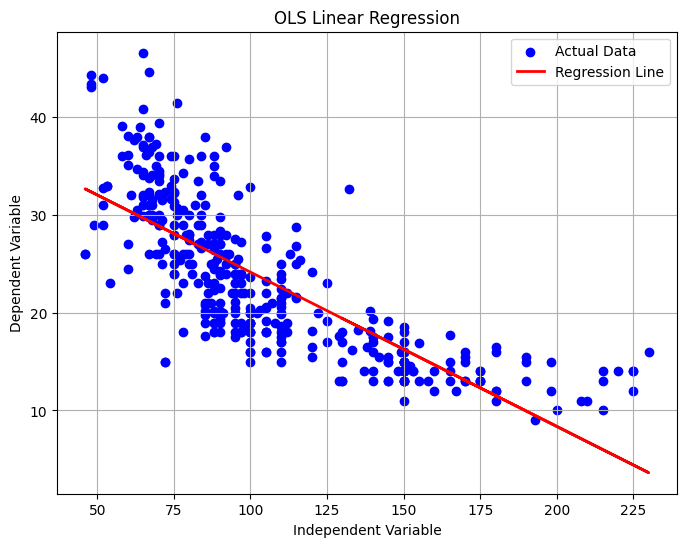

In [ ]:
# ==========================================
# STEP 14: Plot Regression Graph
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(X, Y, color="blue", label="Actual Data")

plt.plot(X, Y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
plt.title("OLS Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

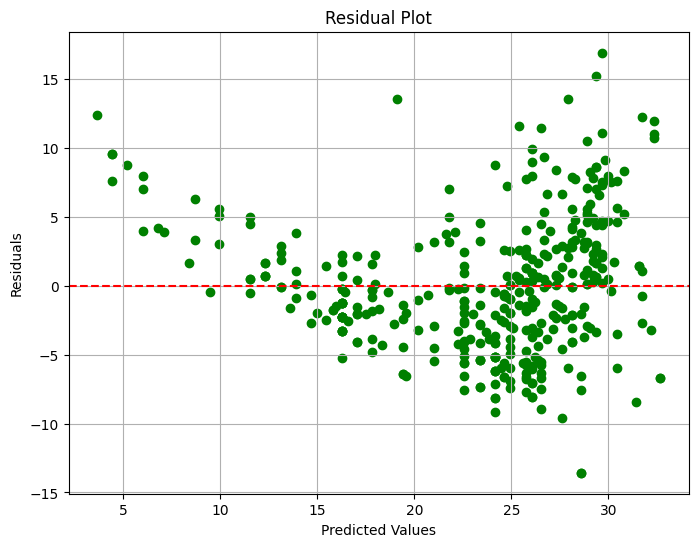

In [ ]:
# ==========================================
# STEP 15: Plot Residual Graph
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(Y_pred, residuals, color="green")

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# STEP 16: Interpret Results
# ==========================================

print("Correlation =", round(correlation,3))
print("Intercept =", round(weights[0],3))
print("Slope =", round(weights[1],3))
print("SSE =", round(SSE,3))
print("MSE =", round(MSE,3))
print("R² =", round(R2,3))

if R2 >= 0.8:
    print("Excellent model fit.")
elif R2 >= 0.6:
    print("Good model fit.")
elif R2 >= 0.4:
    print("Average model fit.")
else:
    print("Poor model fit.")

Correlation = -0.778
Intercept = 39.936
Slope = -0.158
SSE = 9385.916
MSE = 23.944
R² = 0.606
Good model fit.


#Conclusion
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
